In [ ]:
# Переустанавливаем numpy и gensim, чтобы они были совместимы
!pip install --upgrade --force-reinstall numpy gensim
# После этой команды необходимо перезапустить рантайм (Runtime → Restart runtime)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 5.7 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: smart-open
    Found existing installation: s

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Используем max_words=5000, max_len=1000
Фрагментов обучения: 29978, фрагментов теста: 7492


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/4
937/937 ━━━━━━━━━━━━━━━━━━━━ 104s 109ms/step - accuracy: 0.2357 - loss: 2.4811
Epoch 2/4
937/937 ━━━━━━━━━━━━━━━━━━━━ 142s 109ms/step - accuracy: 0.7027 - loss: 0.9985
Epoch 3/4
937/937 ━━━━━━━━━━━━━━━━━━━━ 142s 109ms/step - accuracy: 0.8403 - loss: 0.5341
Epoch 4/4
937/937 ━━━━━━━━━━━━━━━━━━━━ 102s 109ms/step - accuracy: 0.9161 - loss: 0.3034
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step


,Метрика,Значение
0,Точность,0.63
1,Precision (macro),0.59
2,Recall (macro),0.58
3,F1-score (macro),0.58


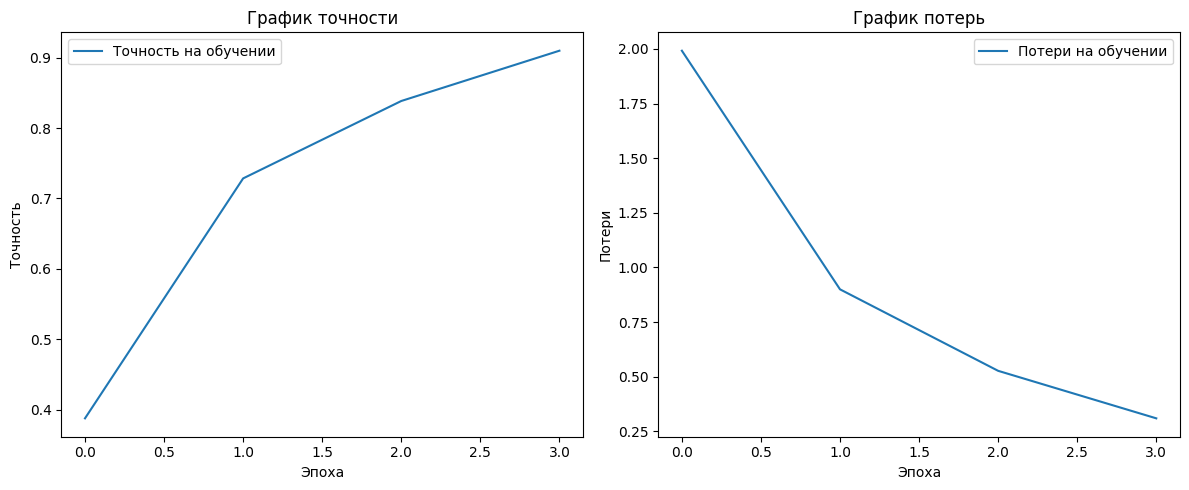

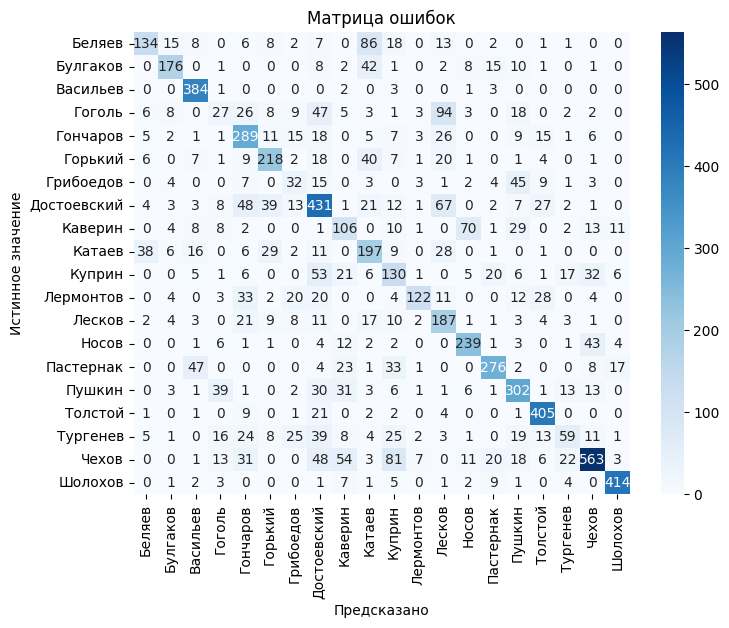

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from google.colab import drive

# Настройка matplotlib для кириллицы
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

def read_full_texts(folder_path, prefix='train_'):
    """
    Считывает полные тексты из .txt файлов префикса prefix.
    Возвращает списки текстов и авторов.
    """
    texts, labels = [], []
    for fn in os.listdir(folder_path):
        if fn.startswith(prefix) and fn.endswith('.txt'):
            author = fn[len(prefix):].replace('.txt','')
            path = os.path.join(folder_path, fn)
            try:
                with open(path, 'r', encoding='utf-8') as f:
                    texts.append(f.read())
            except UnicodeDecodeError:
                with open(path, 'r', encoding='cp1251') as f:
                    texts.append(f.read())
            labels.append(author)
    return texts, labels

def split_into_fixed_fragments(texts, labels, fragment_len=1500, min_len=1000):
    """
    Делит каждый текст на фрагменты длиной fragment_len, счёт идёт с начала до конца.
    Оставляет только те, что >= min_len.
    Возвращает списки фрагментов и их авторов.
    """
    frags, frag_labels = [], []
    for txt, lab in zip(texts, labels):
        for i in range(0, len(txt), fragment_len):
            frag = txt[i:i+fragment_len]
            if len(frag) >= min_len:
                frags.append(frag)
                frag_labels.append(lab)
    return frags, frag_labels

def plot_metrics(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Точность на обучении')
    plt.title('График точности'); plt.xlabel('Эпоха'); plt.ylabel('Точность'); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Потери на обучении')
    plt.title('График потерь'); plt.xlabel('Эпоха'); plt.ylabel('Потери'); plt.legend()

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(labels)))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel('Предсказано'); plt.ylabel('Истинное значение')
    plt.title('Матрица ошибок')
    plt.show()

def print_key_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0)
    df = pd.DataFrame({
        'Метрика': [
            'Точность',
            'Precision (macro)',
            'Recall (macro)',
            'F1-score (macro)'
        ],
        'Значение': [
            f"{acc:.2f}",
            f"{precision:.2f}",
            f"{recall:.2f}",
            f"{f1:.2f}"
        ]
    })
    display(df)

# Сохранение модели и её компонентов
def save_model(model, le, tokenizer, model_path, le_path, tok_path):
    model.save(model_path)                        # Сохраняем Keras-модель
    np.save(le_path, le.classes_)                 # Сохраняем классы LabelEncoder
    with open(tok_path, 'wb') as f:               # Сохраняем Tokenizer
        pickle.dump(tokenizer, f)

if __name__ == '__main__':
    drive.mount('/content/drive')

    base = '/content/drive/MyDrive/Colab Notebooks/Lab_6/Выборка'
    # 1) Считываем 20 полнотекстовых файлов
    train_texts_full, train_labels_full = read_full_texts(os.path.join(base, 'Train'), 'train_')
    test_texts_full,  test_labels_full  = read_full_texts(os.path.join(base, 'Test'),  'test_')

    # 2) Разбиваем на фрагменты фиксированной длины
    fragment_len = 1500
    min_len      = 1000

    train_texts, train_labels = split_into_fixed_fragments(
        train_texts_full, train_labels_full,
        fragment_len=fragment_len,
        min_len=min_len
    )
    test_texts, test_labels = split_into_fixed_fragments(
        test_texts_full, test_labels_full,
        fragment_len=fragment_len,
        min_len=min_len
    )

    # 3) Параметры словаря и длины последовательности
    max_words = 5000
    max_len   = 1000
    print(f"Используем max_words={max_words}, max_len={max_len}")
    print(f"Фрагментов обучения: {len(train_texts)}, фрагментов теста: {len(test_texts)}")

    # 4) Токенизация и паддинг
    tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
    tokenizer.fit_on_texts(train_texts)

    X_train = pad_sequences(
        tokenizer.texts_to_sequences(train_texts),
        maxlen=max_len, padding='post'
    )
    X_test  = pad_sequences(
        tokenizer.texts_to_sequences(test_texts),
        maxlen=max_len, padding='post'
    )

    # 5) Кодирование меток
    le      = LabelEncoder()
    y_train = to_categorical(le.fit_transform(train_labels))
    y_test  = to_categorical(le.transform(test_labels))

    # 6) Модель Embedding + Conv1D
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
        Conv1D(filters=64, kernel_size=5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(32, activation='relu'),
        Dense(y_train.shape[1], activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # 7) Обучение
    history = model.fit(
        X_train, y_train,
        epochs=4,
        batch_size=32,
    )

    # 8) Предсказания и оценка
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)

    print_key_metrics(y_true, y_pred)
    plot_metrics(history)
    plot_confusion_matrix(y_true, y_pred, le.classes_)

    # 9) Сохранение модели
    save_model(
        model, le, tokenizer,
        '/content/drive/MyDrive/Colab Notebooks/Lab_6/Trained_Model/Word_embedding/my_model.h5',
        '/content/drive/MyDrive/Colab Notebooks/Lab_6/Trained_Model/Word_embedding/classes.npy',
        '/content/drive/MyDrive/Colab Notebooks/Lab_6/Trained_Model/Word_embedding/tokenizer.pkl'
    )

In [3]:
import os
import numpy as np
import pickle
from google.colab import drive
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

# Функция предсказания стиля для модели Embedding+Conv1D
def predict_style(model, tokenizer, text, le, max_len):
    # Токенизируем и паддим текст
    seq = tokenizer.texts_to_sequences([text])
    X_input = pad_sequences(seq, maxlen=max_len, padding='post')
    # Получаем вектор вероятностей
    probs = model.predict(X_input)[0]
    top_idx = np.argmax(probs)
    label = le.inverse_transform([top_idx])[0]
    confidence = probs[top_idx]
    return label, confidence

# Загрузка модели, Tokenizer и LabelEncoder
def load_saved_model(model_path, le_path, tok_path):
    model = load_model(model_path)
    le = LabelEncoder()
    le.classes_ = np.load(le_path)
    with open(tok_path, 'rb') as f:
        tokenizer = pickle.load(f)
    return model, tokenizer, le

if __name__ == '__main__':
    drive.mount('/content/drive')

    # Пути к сохранённым файлам
    model_path = '/content/drive/MyDrive/Colab Notebooks/Lab_6/Trained_Model/Word_embedding/my_model.h5'
    le_path    = '/content/drive/MyDrive/Colab Notebooks/Lab_6/Trained_Model/Word_embedding/classes.npy'
    tok_path   = '/content/drive/MyDrive/Colab Notebooks/Lab_6/Trained_Model/Word_embedding/tokenizer.pkl'

    # Параметры, с которыми модель была обучена
    max_len = 1000

    # Загружаем компоненты
    model, tokenizer, le = load_saved_model(model_path, le_path, tok_path)

    # Читаем свой текст
    file_path = '/content/drive/MyDrive/Colab Notebooks/Lab_6/Выборка/test_My.txt'
    with open(file_path, 'r', encoding='utf-8') as f:
        custom_text = f.read()

    # Делаем предсказание
    label, conf = predict_style(model, tokenizer, custom_text, le, max_len)
    print(f'Предсказанный стиль текста: {label} (уверенность: {conf:.2%})')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Предсказанный стиль текста: Чехов (уверенность: 56.71%)
